In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../finance/finance_data.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,product_type,unit_cost,unit_price,quantity,revenue,total_cost,profit,profit_margin,roi
0,2025-04-13,定制工艺品,36.275835,111.523897,37,4126.384182,1342.205879,2784.178303,0.674726,2.074330
1,2025-07-22,艺术摆件,43.287150,65.554456,56,3671.049530,2424.080401,1246.969129,0.339676,0.514409
2,2025-01-02,艺术摆件,38.248053,83.937191,96,8057.970302,3671.813041,4386.157261,0.544325,1.194548
3,2025-08-24,装饰板,21.354541,28.259165,98,2769.398132,2092.744974,676.653158,0.244332,0.323333
4,2025-07-07,定制工艺品,31.386408,74.053493,123,9108.579668,3860.528195,5248.051473,0.576166,1.359413


In [2]:
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
avg_margin = df["profit_margin"].mean()
avg_roi = df["roi"].mean()

print("===== 核心经营指标 =====")
print(f"总收入: {total_revenue:.2f}")
print(f"总利润: {total_profit:.2f}")
print(f"平均利润率: {avg_margin:.2%}")
print(f"平均ROI: {avg_roi:.2f}")

===== 核心经营指标 =====
总收入: 1312515.13
总利润: 703946.23
平均利润率: 49.04%
平均ROI: 1.12


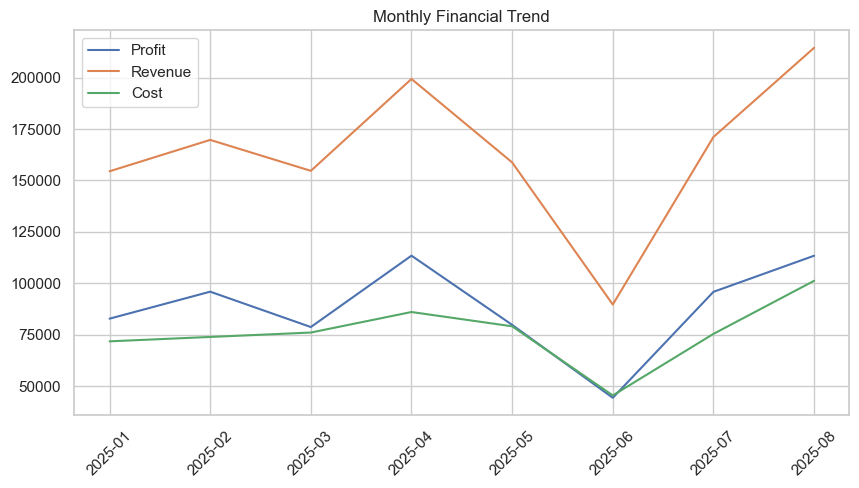

In [ ]:
df["month"] = df["date"].dt.to_period("M")
monthly = df.groupby("month")[["revenue","total_cost","profit"]].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly.index.astype(str), monthly["profit"], label="Profit")
plt.plot(monthly.index.astype(str), monthly["revenue"], label="Revenue")
plt.plot(monthly.index.astype(str), monthly["total_cost"], label="Cost")
plt.title("Monthly Financial Trend")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [4]:
print(df.columns)

Index(['date', 'product_type', 'unit_cost', 'unit_price', 'quantity',
       'revenue', 'total_cost', 'profit', 'profit_margin', 'roi', 'month'],
      dtype='object')


In [6]:
# ==============================
# 1. 先检查数据
# ==============================
print(df.columns)

# ==============================
# 2. 强制构建成本拆分（关键）
# ==============================
df["material_cost"] = df["unit_cost"] * 0.45
df["labor_cost"] = df["unit_cost"] * 0.35
df["energy_cost"] = df["unit_cost"] * 0.20

# ==============================
# 3. 验证是否成功
# ==============================
print(df[["material_cost","labor_cost","energy_cost"]].head())

Index(['date', 'product_type', 'unit_cost', 'unit_price', 'quantity',
       'revenue', 'total_cost', 'profit', 'profit_margin', 'roi', 'month'],
      dtype='object')
   material_cost  labor_cost  energy_cost
0      16.324126   12.696542     7.255167
1      19.479218   15.150503     8.657430
2      17.211624   13.386818     7.649611
3       9.609543    7.474089     4.270908
4      14.123884   10.985243     6.277282


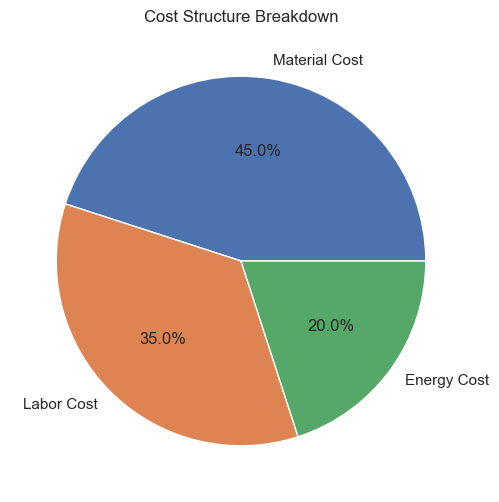

In [7]:
import matplotlib.pyplot as plt

costs = [
    df["material_cost"].sum(),
    df["labor_cost"].sum(),
    df["energy_cost"].sum()
]

labels = ["Material Cost", "Labor Cost", "Energy Cost"]

plt.figure(figsize=(6,6))
plt.pie(costs, labels=labels, autopct="%1.1f%%")
plt.title("Cost Structure Breakdown")
plt.show()

d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35013 (\N{CJK UNIFIED IDEOGRAPH-88C5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39280 (\N{CJK UNIFIED IDEOGRAPH-9970}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26495 (\N{CJK UNIFIED IDEOGRAPH-677F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33402 (\N{CJK UNIFIED IDEOGRAPH-827A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26415 (\N{CJK UNIFIED IDEOGRAPH-672F}) missing from font(s) Arial.
  fig.canvas

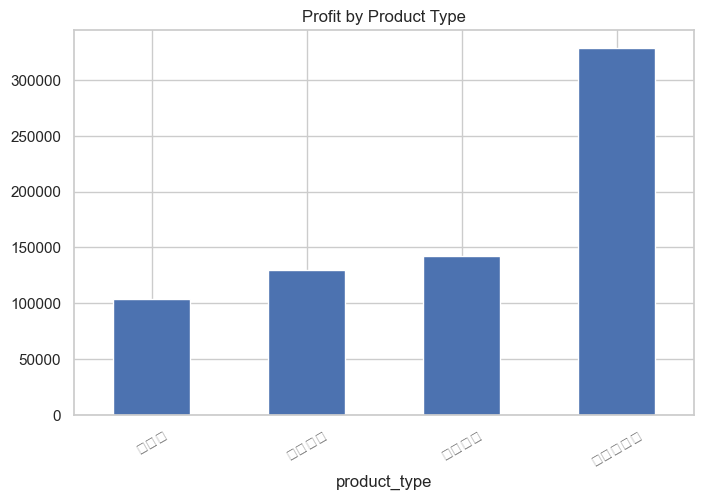

In [8]:
product_profit = df.groupby("product_type")["profit"].sum().sort_values()

plt.figure(figsize=(8,5))
product_profit.plot(kind="bar")
plt.title("Profit by Product Type")
plt.xticks(rotation=30)
plt.show()

d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35013 (\N{CJK UNIFIED IDEOGRAPH-88C5}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39280 (\N{CJK UNIFIED IDEOGRAPH-9970}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26495 (\N{CJK UNIFIED IDEOGRAPH-677F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33402 (\N{CJK UNIFIED IDEOGRAPH-827A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda3\envs\qingcheng\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26415 (\N{CJK UNIFIED IDEOGRAPH-672F}) missing from font(s) Arial.
  fig.canvas

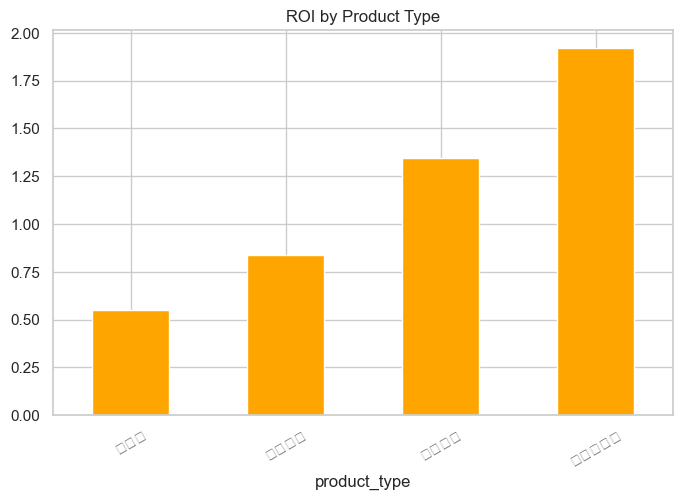

In [9]:
product_roi = df.groupby("product_type")["roi"].mean().sort_values()

plt.figure(figsize=(8,5))
product_roi.plot(kind="bar", color="orange")
plt.title("ROI by Product Type")
plt.xticks(rotation=30)
plt.show()

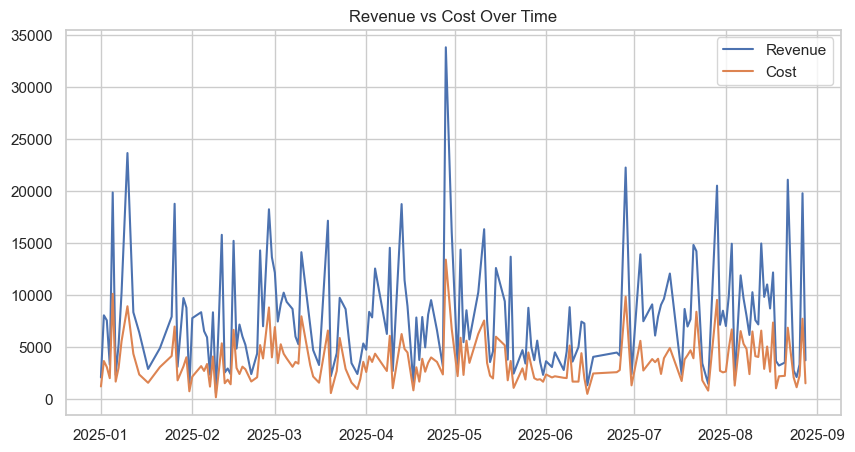

In [10]:
daily = df.groupby("date")[["revenue","total_cost"]].sum()

plt.figure(figsize=(10,5))
plt.plot(daily.index, daily["revenue"], label="Revenue")
plt.plot(daily.index, daily["total_cost"], label="Cost")

plt.title("Revenue vs Cost Over Time")
plt.legend()
plt.show()

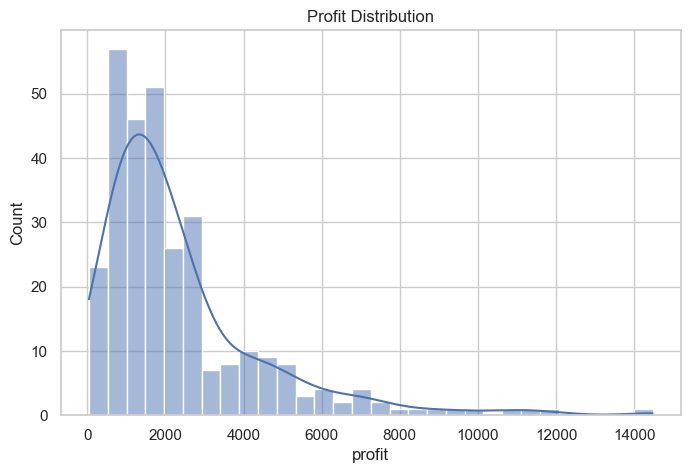

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["profit"], bins=30, kde=True)
plt.title("Profit Distribution")
plt.show()

In [12]:
summary = df.groupby("product_type").agg({
    "revenue":"sum",
    "profit":"sum",
    "roi":"mean"
}).sort_values("profit", ascending=False)

summary

,revenue,profit,roi
product_type,,,
定制工艺品,495954.662632,328127.428640,1.918220
玻璃灯饰,245985.134116,142380.961194,1.345848
艺术摆件,282638.964210,129567.796227,0.837995
装饰板,287936.370073,103870.043746,0.549237
